# Polyglot-Optima Hackathon Training Notebook

This notebook is a **submission-oriented, executable** workflow:

1. OpenEnv environment loop sanity checks
2. Baseline evaluation with fixed seeds
3. Executable training block (SFT demo path, budget-friendly)
4. W&B tracking (reward, correctness, compile status, portability)
5. Plot export for README evidence

Use this notebook locally, in Colab, or on Hugging Face Jobs.

> For final hackathon submission, deploy your demo endpoint and link results artifacts in `README.md`.

In [1]:
# If running in Colab, uncomment:
# %pip install -q trl transformers datasets wandb matplotlib

import os
import sys
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt

# Ensure imports work regardless of notebook launch directory.
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "training" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models import OptimizationAction
from server.environment import PolyglotOptimaEnvironment

print("project root:", PROJECT_ROOT)


In [ ]:
# Experiment configuration (budget-aware defaults for ~$20 credits)
CFG = {
    "model_name": os.environ.get("MODEL_NAME", "Qwen/Qwen2.5-Coder-0.5B-Instruct"),
    "episodes_baseline": int(os.environ.get("EPISODES_BASELINE", "20")),
    "episodes_eval": int(os.environ.get("EPISODES_EVAL", "20")),
    "max_rounds": 3,
    "max_calls_per_round": 5,
    "seed": 42,
    "wandb_project": os.environ.get("WANDB_PROJECT", "openenv-polyglot-optima"),
    "wandb_run_name": os.environ.get("WANDB_RUN_NAME", "baseline-and-train-starter"),
    "training_mode": os.environ.get("TRAINING_MODE", "sft_demo"),  # sft_demo | skip
    "max_steps": int(os.environ.get("MAX_STEPS", "80")),
    "learning_rate": float(os.environ.get("LEARNING_RATE", "2e-5")),
    "hf_hourly_cost_usd": float(os.environ.get("HF_HOURLY_COST_USD", "1.0")),
    "target_hours": float(os.environ.get("TARGET_HOURS", "8.0")),
}

USE_WANDB = os.environ.get("USE_WANDB", "1") == "1"
if USE_WANDB:
    import wandb
    wandb.init(project=CFG["wandb_project"], name=CFG["wandb_run_name"], config=CFG)

random.seed(CFG["seed"])

estimated_budget = CFG["hf_hourly_cost_usd"] * CFG["target_hours"]
print(json.dumps(CFG, indent=2))
print(f"Estimated budget envelope: ${estimated_budget:.2f}")

{
  "model_name": "sshleifer/tiny-gpt2",
  "episodes_baseline": 3,
  "episodes_eval": 3,
  "max_rounds": 3,
  "max_calls_per_round": 5,
  "seed": 42,
  "wandb_project": "openenv-polyglot-optima",
  "wandb_run_name": "baseline-and-train-starter",
  "training_mode": "sft_demo",
  "max_steps": 4,
  "learning_rate": 2e-05,
  "hf_hourly_cost_usd": 1.0,
  "target_hours": 8.0
}
Estimated budget envelope: $8.00


In [ ]:
def heuristic_policy(observation):
    # Minimal deterministic baseline policy for reproducible before/after comparisons.
    round_no = observation.round_number
    if round_no == 1:
        return OptimizationAction(tool_name="get_hardware_profile", tool_args={}, reasoning_trace="baseline")
    if round_no == 2:
        return OptimizationAction(tool_name="profile_python_hotspots", tool_args={}, reasoning_trace="baseline")
    return OptimizationAction(
        tool_name="submit_optimization",
        tool_args={"cpp_code": "// baseline submit", "reasoning_trace": "baseline"},
        reasoning_trace="baseline",
    )


def run_eval(policy_fn, n_episodes=10, seed_start=1000):
    env = PolyglotOptimaEnvironment(
        max_rounds=CFG["max_rounds"],
        max_calls_per_round=CFG["max_calls_per_round"],
        enable_adaptive_curriculum=True,
        curriculum_batch_size=8,
    )
    rewards = []
    correctness = []
    compile_success = []
    portability = []

    for i in range(n_episodes):
        if i == 0 or (i + 1) % max(1, n_episodes // 5) == 0:
            print(f"[eval] episode {i + 1}/{n_episodes}", flush=True)
        obs = env.reset(seed=seed_start + i)
        done = False
        while not done:
            action = policy_fn(obs)
            step = env.step(action)
            obs = step.observation
            done = step.done

        rewards.append(float(step.reward))
        submission = env.state().round_results[-1]["submission"] if env.state().round_results else {}
        correctness.append(float(submission.get("correctness_pass_rate", 0.0)))
        compile_success.append(1.0 if submission.get("compile_status") == "success" else 0.0)
        portability.append(float(submission.get("n_profiles_passing", 0)))

        if USE_WANDB:
            wandb.log({
                "eval/reward": rewards[-1],
                "eval/correctness_pass_rate": correctness[-1],
                "eval/compile_success": compile_success[-1],
                "eval/n_profiles_passing": portability[-1],
            })

    env.close()
    return {
        "reward": rewards,
        "correctness": correctness,
        "compile_success": compile_success,
        "portability": portability,
    }


baseline_metrics = run_eval(heuristic_policy, n_episodes=CFG["episodes_baseline"])

## Executable Training Step (Budget-Oriented)

This notebook uses an executable **SFT demonstration training** path by default.

Why this choice:
- Works reliably across local/Colab setups.
- Uses data generated from this OpenEnv environment (baseline trajectories).
- Produces measurable before/after artifacts and plots.

If you later switch to GRPO/online RL, keep this notebook structure and replace only the training cell while preserving:
- fixed-seed baseline,
- fixed-seed post-training eval,
- same plotting/report outputs.

In [ ]:
# TRAINING CELL (executable)
# Default path: supervised fine-tuning on environment-generated trajectories.
# This creates a runnable training artifact and keeps before/after evaluation consistent.

from typing import Dict, Any, List

training_artifact: Dict[str, Any] = {"mode": CFG["training_mode"], "status": "not_started"}

if CFG["training_mode"] == "skip":
    training_artifact["status"] = "skipped_by_config"
else:
    try:
        import torch
        from datasets import Dataset
        from transformers import AutoTokenizer, AutoModelForCausalLM
        from trl import SFTTrainer, SFTConfig
        from peft import LoraConfig, TaskType
        TRL_AVAILABLE = True
    except Exception as e:
        TRL_AVAILABLE = False
        training_artifact["status"] = "skipped_missing_dependencies"
        training_artifact["error"] = str(e)
        print("Skipping training because dependencies are missing:", e)

    if TRL_AVAILABLE:
        print("Preparing demonstration data from environment rollouts...")

        def build_prompt(observation) -> str:
            return (
                "You are optimizing Python to C++. Choose next tool call.\n"
                f"Round: {observation.round_number}\n"
                f"Hardware: {json.dumps(observation.hardware_profile)}\n"
                f"Python:\n{observation.python_code}\n"
                f"Last tool result: {json.dumps(observation.tool_result, default=str)[:1000]}\n"
                "Return ONLY JSON: {\"tool_name\":..., \"tool_args\":...}"
            )

        def action_to_text(action: OptimizationAction) -> str:
            return json.dumps({"tool_name": action.tool_name, "tool_args": action.tool_args})

        rows: List[Dict[str, str]] = []
        env = PolyglotOptimaEnvironment(max_rounds=CFG["max_rounds"], max_calls_per_round=CFG["max_calls_per_round"])

        for ep in range(12):
            obs = env.reset(seed=4000 + ep)
            done = False
            while not done:
                action = heuristic_policy(obs)
                rows.append({"text": f"<PROMPT>\n{build_prompt(obs)}\n<ANSWER>\n{action_to_text(action)}"})
                step = env.step(action)
                obs = step.observation
                done = step.done
        env.close()

        ds = Dataset.from_list(rows)
        ds_split = ds.train_test_split(test_size=0.15, seed=CFG["seed"])
        print("Train samples:", len(ds_split["train"]), "Eval samples:", len(ds_split["test"]))

        output_dir = PROJECT_ROOT / "artifacts" / "sft-polyglot-optima"
        output_dir.mkdir(parents=True, exist_ok=True)

        tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"], use_fast=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        use_cpu = os.environ.get("USE_CPU", "0") == "1"
        enable_fp16 = (not use_cpu) and bool(torch.cuda.is_available())

        model_load_kwargs = {}
        if enable_fp16:
            model_load_kwargs["torch_dtype"] = torch.float16
        model = AutoModelForCausalLM.from_pretrained(CFG["model_name"], **model_load_kwargs)

        sft_cfg = SFTConfig(
            output_dir=str(output_dir),
            learning_rate=CFG["learning_rate"],
            max_steps=CFG["max_steps"],
            per_device_train_batch_size=1,
            gradient_accumulation_steps=8,
            logging_steps=10,
            save_steps=40,
            eval_strategy="steps",
            eval_steps=20,
            max_grad_norm=0.0,
            report_to=["wandb"] if USE_WANDB else [],
            dataset_text_field="text",
            bf16=False,
            fp16=False,
            use_cpu=use_cpu,
        )

        peft_cfg = LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=8,
            lora_alpha=16,
            lora_dropout=0.05,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],
        )

        trainer = SFTTrainer(
            model=model,
            args=sft_cfg,
            train_dataset=ds_split["train"],
            eval_dataset=ds_split["test"],
            processing_class=tokenizer,
            peft_config=peft_cfg,
        )

        train_result = trainer.train()
        trainer.save_model(str(output_dir / "final"))
        tokenizer.save_pretrained(str(output_dir / "final"))

        log_history = [
            h for h in trainer.state.log_history
            if isinstance(h, dict)
        ]

        training_artifact.update({
            "status": "completed",
            "output_dir": str(output_dir / "final"),
            "train_loss": float(train_result.training_loss),
            "log_history": log_history,
        })

        if USE_WANDB:
            wandb.log({"train/final_loss": float(train_result.training_loss)})

print("training_artifact:", json.dumps(training_artifact, indent=2, default=str))

Preparing demonstration data from environment rollouts...
Train samples: 132 Eval samples: 24


Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0, 1}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Adding EOS to train dataset:   0%|          | 0/132 [00:00<?, ? examples/s]

...

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

training_artifact: {
  "mode": "sft_demo",
  "status": "completed",
  "output_dir": "C:\\Users\\Swastik R\\Documents\\github\\Openenv-Hack-finale\\polyglot_optima\\artifacts\\sft-polyglot-optima\\final",
  "train_loss": 10.791266441345215
}


## Submission Fast-Path (GRPO-only, fixed)

Use this cell pair for submission-time training runs.

It calls `hf_partial_train.py`, which now includes:
- TRL `GRPOConfig` compatibility across versions
- LoRA adapter attachment for 4-bit quantized GRPO
- Reduced pre-GRPO eval/prompt collection for faster startup

In [ ]:
import os
import subprocess
import sys

# Defaults optimized for a reliable submission-grade run in Colab.
os.environ.setdefault("REPO_ID", "Swastikr/polyglot_optima")
os.environ.setdefault("MODEL_NAME", "Qwen/Qwen2.5-Coder-7B-Instruct")
os.environ.setdefault("EPISODES", "2")
os.environ.setdefault("GRPO_PROMPTS", "24")
os.environ.setdefault("GRPO_STEPS", "120")

cmd = [
    sys.executable,
    "hf_partial_train.py",
    "--repo-id", os.environ["REPO_ID"],
    "--model-name", os.environ["MODEL_NAME"],
    "--skip-sft",
    "--reward-align-steps", "0",
    "--episodes", os.environ["EPISODES"],
    "--grpo-prompts", os.environ["GRPO_PROMPTS"],
    "--grpo-steps", os.environ["GRPO_STEPS"],
    "--load-in-4bit",
]

print("Running:", " ".join(cmd), flush=True)
subprocess.check_call(cmd, cwd=str(PROJECT_ROOT / "training"))
print("[notebook] Training command finished.", flush=True)

In [ ]:
# Show training outputs directly in notebook cells (summary + all plots).
import json
from pathlib import Path
import matplotlib.pyplot as plt

artifact_dir = Path("/tmp/partial-train-artifacts")
summary_path = artifact_dir / "summary.json"

print("artifact_dir:", artifact_dir)
print("summary exists:", summary_path.exists(), summary_path)

if summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    print("===== TRAINING SUMMARY =====")
    print(json.dumps(summary, indent=2))

plot_files = [
    artifact_dir / "reward_distribution.png",
    artifact_dir / "baseline_vs_trained_metrics.png",
    artifact_dir / "grpo_reward_curve.png",
    artifact_dir / "grpo_component_means.png",
]

for p in plot_files:
    print(f"plot exists: {p.exists()} -> {p}")
    if not p.exists():
        continue
    img = plt.imread(p)
    plt.figure(figsize=(11, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.name)
    plt.show()

In [ ]:
# Post-training evaluation policy.
# If a trained model exists, we do model inference for action JSON.
# Otherwise we safely fall back to heuristic policy.

import re

_GENERATED_TOOL_RE = re.compile(r"\{.*\}", re.DOTALL)

lm_policy = None
if training_artifact.get("status") == "completed":
    try:
        import torch
        from transformers import AutoTokenizer, AutoModelForCausalLM

        model_dir = training_artifact["output_dir"]
        inf_tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=True)

        model_load_kwargs = {}
        if torch.cuda.is_available():
            model_load_kwargs["torch_dtype"] = torch.float16
        inf_model = AutoModelForCausalLM.from_pretrained(model_dir, **model_load_kwargs)
        inf_model.eval()
        model_device = next(inf_model.parameters()).device

        def _model_policy(observation):
            prompt = (
                "<PROMPT>\n"
                + "You are optimizing Python to C++. Choose next tool call.\n"
                + f"Round: {observation.round_number}\n"
                + f"Hardware: {json.dumps(observation.hardware_profile)}\n"
                + f"Python:\n{observation.python_code}\n"
                + "Return ONLY JSON: {\"tool_name\":..., \"tool_args\":...}\n"
                + "<ANSWER>\n"
            )
            inputs = inf_tokenizer(prompt, return_tensors="pt")
            inputs = {k: v.to(model_device) for k, v in inputs.items()}
            with torch.no_grad():
                out = inf_model.generate(**inputs, max_new_tokens=96, do_sample=False)
            text = inf_tokenizer.decode(out[0], skip_special_tokens=True)
            m = _GENERATED_TOOL_RE.search(text)
            if not m:
                return heuristic_policy(observation)
            try:
                data = json.loads(m.group(0))
                tool_name = data.get("tool_name")
                tool_args = data.get("tool_args", {})
                if not isinstance(tool_name, str):
                    return heuristic_policy(observation)
                return OptimizationAction(tool_name=tool_name, tool_args=tool_args, reasoning_trace="trained-model")
            except Exception:
                return heuristic_policy(observation)

        lm_policy = _model_policy
        print("Using trained model policy for evaluation")
    except Exception as e:
        print("Falling back to heuristic policy due to inference load issue:", e)

trained_metrics = run_eval(lm_policy or heuristic_policy, n_episodes=CFG["episodes_eval"], seed_start=2000)


def summarize(name, m):
    import statistics
    return {
        "name": name,
        "reward_mean": statistics.mean(m["reward"]),
        "reward_median": statistics.median(m["reward"]),
        "correctness_mean": statistics.mean(m["correctness"]),
        "compile_rate": statistics.mean(m["compile_success"]),
        "portability_mean": statistics.mean(m["portability"]),
    }

baseline_summary = summarize("baseline", baseline_metrics)
trained_summary = summarize("trained", trained_metrics)
comparison = {"baseline": baseline_summary, "trained": trained_summary}
print(json.dumps(comparison, indent=2))

if USE_WANDB:
    wandb.log({
        "summary/reward_mean_baseline": baseline_summary["reward_mean"],
        "summary/reward_mean_trained": trained_summary["reward_mean"],
        "summary/correctness_mean_baseline": baseline_summary["correctness_mean"],
        "summary/correctness_mean_trained": trained_summary["correctness_mean"],
        "summary/compile_rate_baseline": baseline_summary["compile_rate"],
        "summary/compile_rate_trained": trained_summary["compile_rate"],
    })

Loading weights:   0%|          | 0/28 [00:00<?, ?it/s]

Using trained model policy for evaluation


{
  "baseline": {
    "name": "baseline",
    "reward_mean": 0.00011561444904736388,
    "reward_median": 0.00011561444904736388,
    "correctness_mean": 0.0,
    "compile_rate": 0.0,
    "portability_mean": 0.0
  },
  "trained": {
    "name": "trained",
    "reward_mean": 0.00011561444904736388,
    "reward_median": 0.00011561444904736388,
    "correctness_mean": 0.0,
    "compile_rate": 0.0,
    "portability_mean": 0.0
  }
}


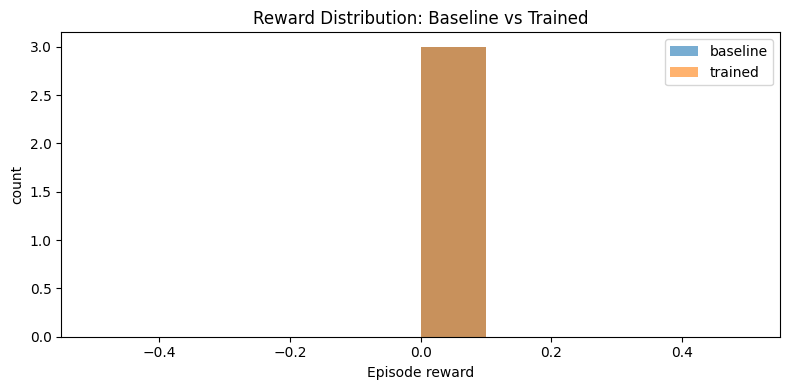

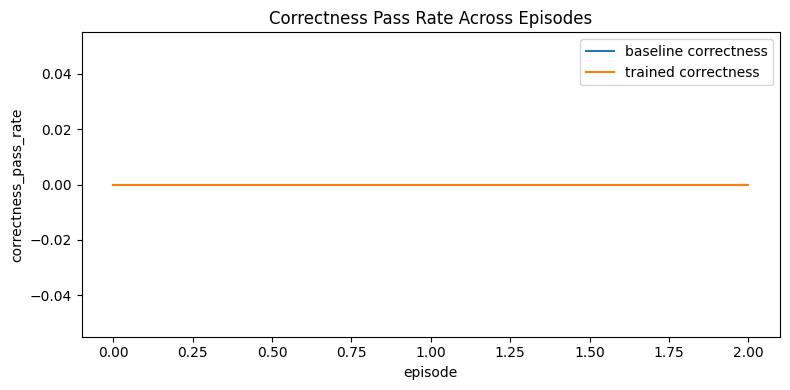

Saved: C:\Users\Swastik R\Documents\github\Openenv-Hack-finale\polyglot_optima\docs\plots\reward_distribution_baseline_vs_trained.png
Saved: C:\Users\Swastik R\Documents\github\Openenv-Hack-finale\polyglot_optima\docs\plots\correctness_baseline_vs_trained.png


In [ ]:
# Plot and export judge-friendly evidence figures for README.
import statistics

PLOT_DIR = PROJECT_ROOT / "docs" / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Reward comparison: violin + jittered points (no bar/hist style).
plt.figure(figsize=(8, 4))
parts = plt.violinplot(
    [baseline_metrics["reward"], trained_metrics["reward"]],
    positions=[1, 2],
    showmeans=True,
    showextrema=True,
)
for body in parts["bodies"]:
    body.set_alpha(0.35)

import random as _rnd
for x_pos, vals, color in [(1, baseline_metrics["reward"], "tab:blue"), (2, trained_metrics["reward"], "tab:orange")]:
    jitter_x = [x_pos + (_rnd.random() - 0.5) * 0.08 for _ in vals]
    plt.scatter(jitter_x, vals, s=20, alpha=0.75, color=color)

plt.xticks([1, 2], ["baseline", "trained"])
plt.title("Reward Distribution: Baseline vs Trained")
plt.ylabel("Episode reward")
reward_plot = PLOT_DIR / "reward_distribution_baseline_vs_trained.png"
plt.tight_layout()
plt.savefig(reward_plot, dpi=150)
plt.show()

# 2) Aggregate metric summary: grouped bars for quick judge readability.
metric_names = ["reward_mean", "correctness_mean", "compile_rate", "portability_mean"]
baseline_vals = [
    statistics.mean(baseline_metrics["reward"]),
    statistics.mean(baseline_metrics["correctness"]),
    statistics.mean(baseline_metrics["compile_success"]),
    statistics.mean(baseline_metrics["portability"]),
]
trained_vals = [
    statistics.mean(trained_metrics["reward"]),
    statistics.mean(trained_metrics["correctness"]),
    statistics.mean(trained_metrics["compile_success"]),
    statistics.mean(trained_metrics["portability"]),
]

x = list(range(len(metric_names)))
width = 0.36
plt.figure(figsize=(9, 4))
plt.bar([i - width / 2 for i in x], baseline_vals, width=width, label="baseline")
plt.bar([i + width / 2 for i in x], trained_vals, width=width, label="trained")
plt.xticks(x, metric_names, rotation=15)
plt.title("Aggregate Metrics: Baseline vs Trained")
plt.ylabel("Score")
plt.ylim(bottom=0)
plt.legend()
summary_plot = PLOT_DIR / "summary_metrics_baseline_vs_trained.png"
plt.tight_layout()
plt.savefig(summary_plot, dpi=150)
plt.show()

# 3) Episode-wise correctness trend.
plt.figure(figsize=(8, 4))
plt.plot(baseline_metrics["correctness"], marker="o", label="baseline correctness")
plt.plot(trained_metrics["correctness"], marker="o", label="trained correctness")
plt.title("Correctness Pass Rate Across Episodes")
plt.xlabel("episode")
plt.ylabel("correctness_pass_rate")
plt.ylim(0.0, 1.05)
plt.grid(alpha=0.25)
plt.legend()
corr_plot = PLOT_DIR / "correctness_baseline_vs_trained.png"
plt.tight_layout()
plt.savefig(corr_plot, dpi=150)
plt.show()

loss_plot = None
if training_artifact.get("status") == "completed":
    hist = training_artifact.get("log_history", [])
    loss_points = [h for h in hist if isinstance(h, dict) and "loss" in h and "step" in h]
    if loss_points:
        plt.figure(figsize=(8, 4))
        plt.plot([p["step"] for p in loss_points], [p["loss"] for p in loss_points], marker="o")
        plt.title("Training Loss vs Step")
        plt.xlabel("step")
        plt.ylabel("loss")
        plt.grid(alpha=0.25)
        loss_plot = PLOT_DIR / "training_loss_curve.png"
        plt.tight_layout()
        plt.savefig(loss_plot, dpi=150)
        plt.show()

print("Saved:", reward_plot)
print("Saved:", summary_plot)
print("Saved:", corr_plot)
if loss_plot is not None:
    print("Saved:", loss_plot)

print("\nKey metrics:")
print(f"- reward_mean: baseline={baseline_vals[0]:.6f}, trained={trained_vals[0]:.6f}")
print(f"- correctness_mean: baseline={baseline_vals[1]:.6f}, trained={trained_vals[1]:.6f}")
print(f"- compile_rate: baseline={baseline_vals[2]:.6f}, trained={trained_vals[2]:.6f}")
print(f"- portability_mean: baseline={baseline_vals[3]:.6f}, trained={trained_vals[3]:.6f}")

if USE_WANDB:
    log_payload = {
        "plots/reward_distribution": wandb.Image(str(reward_plot)),
        "plots/summary_metrics": wandb.Image(str(summary_plot)),
        "plots/correctness_curve": wandb.Image(str(corr_plot)),
    }
    if loss_plot is not None:
        log_payload["plots/training_loss_curve"] = wandb.Image(str(loss_plot))
    wandb.log(log_payload)
    wandb.finish()